In [1]:
import regina
import snappy
import sys
import json
import time
load('wild_mosaics.py')
sys.setrecursionlimit(10000)

def random_mosaic_time(dimension, suitably_connected = True, num_crossings = -1, num_components = -1, _depth = 0, start_time = -1):
    # Prevents infinite recursion
    if _depth > 10000:
        raise ValueError("Could not generate mosaic satisfying constraints after 5000 attempts")

    # Generate base mosaic
    if suitably_connected:
        template = matrix(ZZ, dimension, dimension)
        for i in range(dimension):
            for j in range(dimension):
                template[i,j] = choice(Mosaic(template).potential_tiles(i,j))
        M = Mosaic(template)
    else:
        M = Mosaic(random_matrix(GF(11), dimension, dimension))
    
    # Check constraints (if given)
    crossing_validity = (num_crossings == -1) or (M.numCrossings() == num_crossings)
    component_validity = (num_components == -1) or (M.numComponents() == num_components)

    if crossing_validity and component_validity:
        end_time = time.time()
        total_time = end_time - start_time
        return {'mosaic_size': int(dimension), 'search_depth':int(_depth), 'compute_time': float(total_time)}
    else:
        return random_mosaic_time(dimension, suitably_connected, num_crossings, num_components, _depth + 1, start_time)



In [ ]:
import regina
import snappy
import sys
import json
import time
load('wild_mosaics.py')
sys.setrecursionlimit(10000)

def random_mosaic_time(dimension, suitably_connected = True, num_crossings = -1, num_components = -1, _depth = 0, start_time = -1):
    # Prevents infinite recursion
    if _depth > 10000:
        raise ValueError("Could not generate mosaic satisfying constraints after 5000 attempts")

    # Generate base mosaic
    if suitably_connected:
        template = matrix(ZZ, dimension, dimension)
        for i in range(dimension):
            for j in range(dimension):
                template[i,j] = choice(Mosaic(template).potential_tiles(i,j))
        M = Mosaic(template)
    else:
        M = Mosaic(random_matrix(GF(11), dimension, dimension))
    
    # Check constraints (if given)
    crossing_validity = (num_crossings == -1) or (M.numCrossings() == num_crossings)
    component_validity = (num_components == -1) or (M.numComponents() == num_components)

    if crossing_validity and component_validity:
        end_time = time.time()
        total_time = end_time - start_time
        return {'mosaic_size': int(dimension), 'search_depth':int(_depth), 'compute_time': float(total_time)}
    else:
        return random_mosaic_time(dimension, suitably_connected, num_crossings, num_components, _depth + 1, start_time)



In [ ]:
data = []

In [ ]:
for i in range(100):
    for j in range(5, 16):
        M = random_mosaic_time(dimension = j, num_components = 1, start_time = time.time())
        data.append(M)

In [ ]:
for i in range(20):
    M = random_mosaic_time(dimension = 18, num_components = 1, start_time = time.time())
    data.append(M)


In [ ]:
with open('timeData.json', 'w') as f:
    json.dump(data, f, indent=2)

In [ ]:
with open("timeData.json", "r") as file:
    read_data = json.load(file)

for row in read_data

In [ ]:
M = random_mosaic(dimension = 17)
M.show(17)

In [3]:
import random
import copy 

def combine_components(mosaic,tile=-1, _depth=0):
    if _depth > 5000:
        raise ValueError("Could not generate mosaic satisfying constraints after 5000 attempts")
    
    
    M = copy.copy(mosaic.matrixRepresentation)
    strands = mosaic.strands()
    if tile == -1:    # If tile is not set, pick a random nonzero tile to start on
        longest_strand = max(strands, key=len)
        tile = random.choice(longest_strand)
    
    strand = mosaic.strandOf(tile)
    _strandMatrix = mosaic.strandMatrix()

    for tile in strand:
        _strandMatrix[tile[0],tile[1]] -= 1

    for tile in strand:
        if int(_strandMatrix[tile[0],tile[1]]) == int(1):
            tile_type = int(M[tile[0],tile[1]])
            if tile_type == int(7):
                M[tile[0],tile[1]] = 8
            elif tile_type == int(8):
                M[tile[0],tile[1]] = 7
            elif tile_type == int(9):
                M[tile[0],tile[1]] = random.choice([7,8])
            elif tile_type == int(10):
                M[tile[0],tile[1]] = random.choice([7,8])

            return combine_components(Mosaic(M),tile, _depth+1)
    
    for i in range(M.nrows()):
        for j in range(M.ncols()):
            if (i,j) not in strand:
                M[i,j] = Integer(0)

    return Mosaic(M)



In [28]:
size = 20
start = time.time()
L = random_mosaic(dimension = size)
end1 = time.time()
strand = random.choice(L.strands())
K = combine_components(L)
end2 = time.time()
M = orientedGaussCode(K).remove_loops()
M = Link(M)

end3 = time.time()
print("Time to generate base mosaic: ", end1 - start)
print("Time to combine components: ", end2 - end1)
print("Time to create link and remove loops: ", end3 - end2)
print("Number of components in original mosaic: ", L.numComponents())
print("Number of crossings in original mosaic: ", L.numCrossings())
print("Number of crossings in combined mosaic: ", K.numCrossings())
print("Number of crossings after removing loops: ", len(M.pd_code))



AttributeError: 'list' object has no attribute 'remove_loops'

In [27]:
print(M.pd_code())
flat = flatten(M.pd_code())
print(set(flat))
for i in set(flat):
    print(flat.count(i))

[[2, 72, 3, 71], [62, 62, 63, 61], [3, 4, 4, 5], [8, 5, 9, 6], [63, 10, 64, 11], [59, 60, 60, 61], [64, 68, 65, 67], [11, 67, 12, 66], [24, 36, 25, 35], [33, 48, 34, 49], [17, 46, 18, 47], [16, 52, 17, 51], [15, 52, 16, 53], [42, 53, 43, 54], [56, 56, 57, 55], [72, 2, 1, 1], [70, 7, 71, 8], [6, 69, 7, 70], [9, 68, 10, 69], [28, 27, 29, 28], [65, 13, 66, 12], [38, 14, 39, 13], [22, 29, 23, 30], [18, 21, 19, 22], [19, 21, 20, 20], [39, 58, 40, 59], [30, 23, 31, 24], [26, 37, 27, 38], [36, 31, 37, 32], [34, 50, 35, 49], [47, 50, 48, 51], [45, 14, 46, 15], [41, 45, 42, 44], [40, 58, 41, 57], [25, 32, 26, 33], [54, 43, 55, 44]]
{1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72}
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2

In [16]:
M = random_mosaic(dimension = 20)
strand = random.choice(M.strands())
N = combine_components(M)

sageLink = Link(orientedGaussCode(N)) 
print("sageLink made")
K = sageLink.jones_polynomial(algorithm = 'statesum').coefficients()
print(len(K))

sageLink made


KeyboardInterrupt: 

In [ ]:
print(J.numComponents())
print(L.numComponents())

 for tile in strand:
        _strandMatrix[tile[0],tile[1]] -= 1


    for tile in strand:
        if int(_strandMatrix[tile[0],tile[1]]) == int(1):
            print(M[tile[0],tile[1]])
            print(tile)
            tile_type = int(M[tile[0],tile[1]])
            if tile_type == int(7):
                M[tile[0],tile[1]] = 8
            elif tile_type == int(8):
                M[tile[0],tile[1]] = 7
            elif tile_type == int(9):
                M[tile[0],tile[1]] = 8
            elif tile_type == int(10):
                M[tile[0],tile[1]] = 8

            return Mosaic(M) #combine_components(Mosaic(M), 1 + _depth)

2
2


In [ ]:
print(type(Integer(7)))

            match M[tile[0],tile[1]]:
                case 7:
                    M[tile[0],tile[1]] = 8
                case 8:
                    M[tile[0],tile[1]] = 7
                case 9:
                    M[tile[0],tile[1]] = 7
                case 10:
                    M[tile[0],tile[1]] = 8

<class 'sage.rings.integer.Integer'>


[[(0, 1), (1, 1), (1, 0), (0, 0)], [(1, 3), (2, 3), (2, 4), (3, 4), (3, 3), (4, 3), (4, 2), (3, 2), (3, 1), (3, 0), (2, 0), (2, 1), (2, 2), (1, 2)]]
2


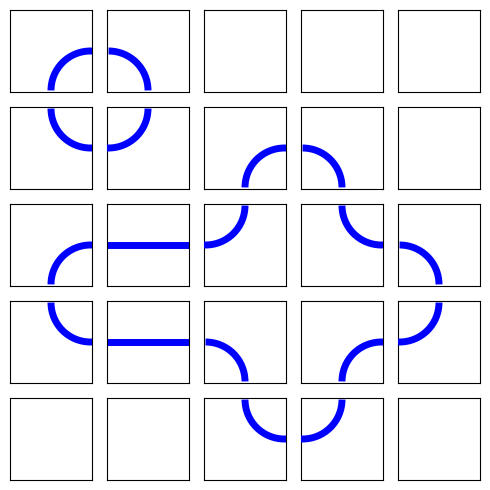

In [47]:
K = random_mosaic(dimension = 5)
M = K.matrixRepresentation
print(K.strands())
print(len(K.strands()))
K.show()